In [17]:
# Phase 1 — Data Foundation (Transactions Layer)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

df = pd.read_csv('/content/drive/MyDrive/PS_20174392719_1491204439457_log.csv')

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.shape

(6362620, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
transactions = df.copy()

transactions = transactions.rename(columns={
    "nameOrig":"Customer_ID",
    "step":"Transaction_Hour",
    "amount":"Amount",
    "isFraud":"Fraud_Label"
})

In [9]:
transactions["Transaction_ID"] = range(1, len(transactions)+1)

In [10]:
transactions = transactions[[
"Transaction_ID",
"Customer_ID",
"Transaction_Hour",
"type",
"Amount",
"Fraud_Label"
]]

In [11]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Hour"],
    unit="h",
    origin="2020-01-01"
)

In [12]:
transactions.duplicated().sum()

np.int64(0)

In [13]:
transactions.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Transaction_Hour,0
type,0
Amount,0
Fraud_Label,0
Transaction_Date,0


In [14]:
transactions["Fraud_Label"].value_counts()

,count
Fraud_Label,
0,6354407
1,8213


In [15]:
fraud_rate = transactions["Fraud_Label"].mean()
print("Fraud Rate:", fraud_rate)

Fraud Rate: 0.001290820448180152


In [18]:
transactions["type"].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [19]:
transactions.groupby("Fraud_Label")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Fraud_Label,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [20]:
fraud_by_day = transactions.groupby(
    transactions["Transaction_Date"].dt.date
)["Fraud_Label"].sum()

<Axes: xlabel='Transaction_Date'>

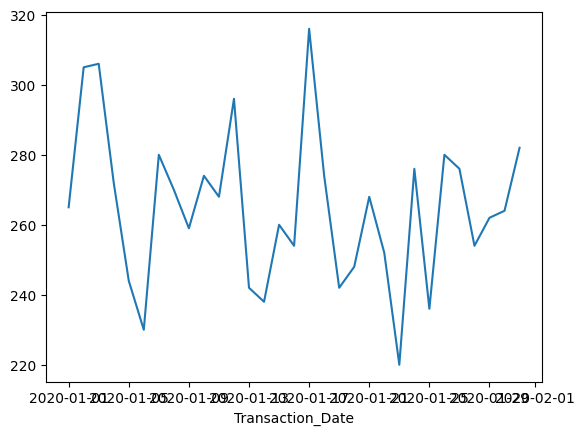

In [21]:
fraud_by_day.plot()

<Axes: xlabel='Amount', ylabel='Count'>

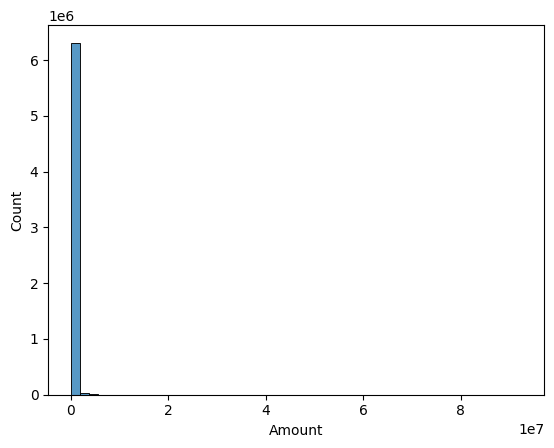

In [22]:
sns.histplot(transactions["Amount"], bins=50)

<Axes: xlabel='Fraud_Label', ylabel='Amount'>

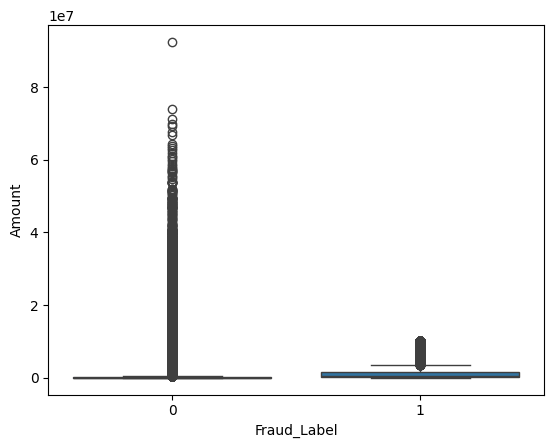

In [23]:
sns.boxplot(
    x="Fraud_Label",
    y="Amount",
    data=transactions
)

In [24]:
transactions.to_csv("transactions_clean.csv", index=False)